In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
from sklearn.datasets import make_classification

In [5]:
X,y=make_classification(n_samples=1000,n_features=2,n_informative=2,n_redundant=0,random_state=42)

In [6]:
df=pd.DataFrame(X)

In [7]:
df['Target']=y

In [8]:
df

,0,1,Target
0,-0.999102,-0.663860,1
1,1.246686,1.153597,1
2,0.962777,0.859397,1
3,-2.957441,2.033645,1
4,1.141165,1.059449,1
...,...,...,...
995,-0.432774,0.890930,0
996,1.020438,1.164617,1
997,-0.101267,-1.590176,0
998,0.643761,-0.780539,0


In [9]:
from sklearn.linear_model import Perceptron

In [10]:
p=Perceptron()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.3,stratify=y)

In [13]:
X_train.shape

(700, 2)

In [14]:
y_train.shape

(700,)

In [15]:
p.fit(X_train,y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [16]:
from sklearn.metrics import accuracy_score

In [17]:
y_pred=p.predict(X_test)

In [18]:
accuracy_score(y_test,y_pred)

0.8766666666666667

In [19]:
p.coef_

array([[0.22652072, 2.38892863]])

In [20]:
p.intercept_

array([0.])

In [21]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

<Axes: >

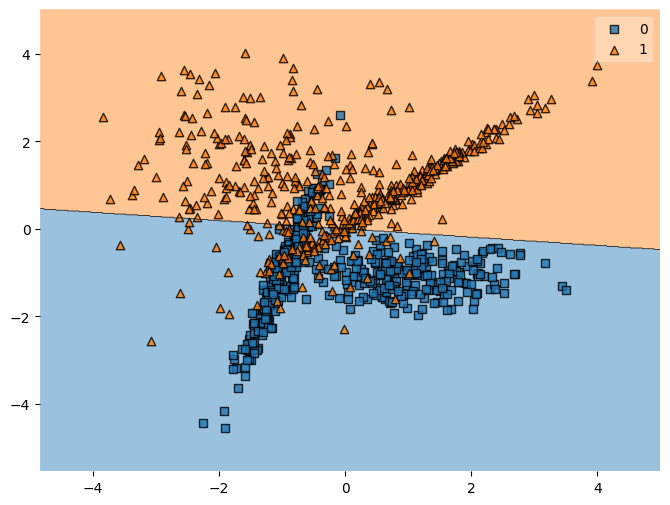

In [22]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X,y,clf=p)

XOR Accuracy: 50.0 %


Text(0, 0.5, 'Input X2')

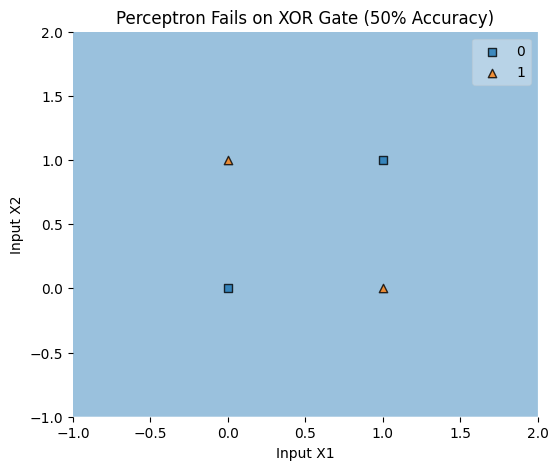

In [24]:
# Demonstrating the XOR Problem (Linear Inseparability)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Fit Perceptron on XOR Gate
p_xor = Perceptron()
p_xor.fit(X_xor, y_xor)

print("XOR Accuracy:", accuracy_score(y_xor, p_xor.predict(X_xor)) * 100, "%")

# Plot Decision Boundary
plt.figure(figsize=(6, 5))
plot_decision_regions(X_xor, y_xor, clf=p_xor)
plt.title("Perceptron Fails on XOR Gate (50% Accuracy)")
plt.xlabel("Input X1")
plt.ylabel("Input X2")
# plt.show()